# EDA

In [2]:
# STEP 1: Setup + load data + windowing (train-only scaling)

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [3]:
import os
print(os.listdir())

['sirikit', 'knn_radius_distribution_30.png', '7_sirikit_bivariate', 'Sirikit_MULTIVARIATE-Copy1.ipynb', 'phase1-srikit.ipynb', 'sirikit_soill1_prediction.ipynb', 'latent_train_seq_bi_7.npy', 'Phase 2-1 day.ipynb', 'cache_bi7', 'Sirikit_upstream_full_multivariate_daily.csv', 'cache', '7_Sirikit_BIVARIATE.ipynb', 'zigzag_train_per_frame_bi_30.npy', 'Sirikit_BIVARIATE.ipynb', 'zigzag_test_per_sample_bi_30.npy', '7_univarite.ipynb', 'cf_30_univariate-Copy1.ipynb', 'latent_test_seq_bi_7.npy', 'zigzag_train_per_frame_bi_7.npy', '7_sirikit_bivarite', 'latent_train_seq_bi_30.npy', 'latent_test_seq_bi_30.npy', 'y_scaler_bivariate_7.save', '30_univariate.ipynb', 'y_scaler_bivariate_30.save', 'zigzag_train_per_sample_bi_7.npy', 'cache_bi30', '30_Sirikit_BIVARIATE.ipynb', 'Forecast_Error_Extreme_Reservoir_Conditions.png', '30_best_model_bivariate.pth', 'zigzag_test_per_frame_bi_30.npy', 'y_true_test_bi_7.npy', 'Phase 2- 30 days.ipynb', '.ipynb_checkpoints', 'knn_radius_distribution_7.png', 'zigza

In [4]:
CSV_PATH = r"../MSEA-Res_database_v2/Dynamic_components/Level2/Level2_5140_1974_Sirikit.csv"
#MSEA-Res_database_v2/Dynamic_components/Level2/Level2_5140_1974_Sirikit.csv
df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").dropna(subset=["Storage_km3"]).reset_index(drop=True)

print("Data shape:", df.shape)
print(df.head())
print(df.tail())

Data shape: (13169, 2)
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153


In [5]:

# ----------------------------
# 2) Temporal split (train past, test future)
# ----------------------------
cutoff = pd.Timestamp("2016-01-01")  # same idea as before; change if you want
train_df = df[df["Date"] < cutoff].copy()
test_df  = df[df["Date"] >= cutoff].copy()

print("\nTrain:", train_df["Date"].min(), "→", train_df["Date"].max(), "n =", len(train_df))
print("Test :", test_df["Date"].min(),  "→", test_df["Date"].max(),  "n =", len(test_df))



Train: 1987-12-12 00:00:00 → 2015-12-31 00:00:00 n = 10247
Test : 2016-01-01 00:00:00 → 2023-12-31 00:00:00 n = 2922


In [6]:

# ----------------------------
# 3) Scale using TRAIN only
# ----------------------------
scaler = StandardScaler().fit(train_df[["Storage_km3"]])
train_s = scaler.transform(train_df[["Storage_km3"]]).flatten()
test_s  = scaler.transform(test_df[["Storage_km3"]]).flatten()

# ----------------------------
# 4) Make supervised windows
# ----------------------------
def make_windows(series, lookback=180, horizon=1, stride=1):
    """
    series: 1D array
    returns:
      X: [N, lookback, 1]
      y: [N] if horizon=1 else [N, horizon]
    """
    X, y = [], []
    for i in range(0, len(series) - lookback - horizon + 1, stride):
        X.append(series[i:i+lookback])
        y.append(series[i+lookback:i+lookback+horizon])
    X = np.asarray(X)[:, :, None]
    y = np.asarray(y).squeeze()
    return X, y

LOOKBACK = 180
HORIZON  = 30

X_train, y_train = make_windows(train_s, lookback=LOOKBACK, horizon=HORIZON)
X_test,  y_test  = make_windows(test_s,  lookback=LOOKBACK, horizon=HORIZON)

print("\nWindowed shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


Windowed shapes:
X_train: (10038, 180, 1) y_train: (10038, 30)
X_test : (2713, 180, 1) y_test : (2713, 30)


# Model Training

In [7]:
# STEP 2: BiLSTM training + latent extraction

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# 1) Convert numpy -> torch
# ----------------------------
def to_t(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

train_ds = TensorDataset(to_t(X_train), to_t(y_train))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

test_X = to_t(X_test)
test_y = to_t(y_test)
# ----------------------------
# 2) Define BiLSTM that can return latent sequence
# ----------------------------
class BiLSTM_Inspect(nn.Module):
    def __init__(self, in_dim=1, hidden=128, layers=2, dropout=0.3, out_dim=30):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, num_layers=layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.fc = nn.Linear(hidden * 2, out_dim)

    def forward(self, x, return_hidden=False):
        out, (h, c) = self.lstm(x)       # out: [B, T, 2H]
        y = self.fc(out[:, -1, :])       # forecast using last timestep
        if return_hidden:
            return y, out                # out is the full latent sequence
        return y

model = BiLSTM_Inspect(out_dim=30).to(device)


Device: cpu


In [21]:
# xb, yb = next(iter(tr_dl))
# print(xb.shape, yb.shape)
# print(model(xb).shape)

In [8]:
VAL_FRAC = 0.15
n_tr = len(X_train)
n_val = int(n_tr * VAL_FRAC)

# time-based val (take last chunk of training)
X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
X_val, y_val = X_train[-n_val:], y_train[-n_val:]

tr_dl = DataLoader(
    TensorDataset(to_t(X_tr), to_t(y_tr)),
    batch_size=64,
    shuffle=True
)
val_X, val_y = to_t(X_val), to_t(y_val)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

best_val = float("inf")
patience = 20
bad = 0

for epoch in range(400):
    # ---- train ----
    model.train()
    running = 0.0
    for xb, yb in tr_dl:
        opt.zero_grad()
        pred = model(xb)                 # [B, 30]
        loss = loss_fn(pred, yb)         # yb is [B, 30]
        loss.backward()
        opt.step()
        running += loss.item() * len(xb)
    train_loss = running / len(tr_dl.dataset)

    # ---- validate ----
    model.eval()
    with torch.no_grad():
        vpred = model(val_X)             # [N_val, 30]
        val_loss = loss_fn(vpred, val_y).item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | train {train_loss:.6f} | val {val_loss:.6f}")

    # ---- early stopping ----
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

# restore best model
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ----------------------------
# 4) Forecast on test + invert scaling back to km^3
# ----------------------------
model.eval()
with torch.no_grad():
    y_pred_s = model(test_X).cpu().numpy()      # shape [N, 30]

y_true_s = test_y.cpu().numpy()                 # shape [N, 30]

# invert scaling (requires scaler from Step 1)
y_pred = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1, 30)
y_true = scaler.inverse_transform(y_true_s.reshape(-1, 1)).reshape(-1, 30)

# overall metrics across all forecasted values
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae  = np.mean(np.abs(y_true - y_pred))
r2   = r2_score(y_true.reshape(-1), y_pred.reshape(-1))

print(f"\n[Test Forecast] RMSE={rmse:.6f} km³ | MAE={mae:.6f} km³ | R²={r2:.6f}")

# per-day metrics
print("\nPer-horizon metrics:")
for h in range(30):
    rmse_h = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
    mae_h  = mean_absolute_error(y_true[:, h], y_pred[:, h])
    r2_h   = r2_score(y_true[:, h], y_pred[:, h])
    print(f"Day {h+1:02d}: RMSE={rmse_h:.6f} | MAE={mae_h:.6f} | R²={r2_h:.6f}")

# Save the best trained model
torch.save(model.state_dict(), "best_model_srikit_30day.pth")
print("Model saved as best_model_srikit_30day.pth")

Epoch  10 | train 0.088659 | val 0.053696
Epoch  20 | train 0.070416 | val 0.070982
Early stopping.

[Test Forecast] RMSE=0.372836 km³ | MAE=0.243414 km³ | R²=0.904955

Per-horizon metrics:
Day 01: RMSE=0.096705 | MAE=0.070425 | R²=0.993677
Day 02: RMSE=0.083648 | MAE=0.064090 | R²=0.995265
Day 03: RMSE=0.097350 | MAE=0.071605 | R²=0.993582
Day 04: RMSE=0.102262 | MAE=0.074978 | R²=0.992913
Day 05: RMSE=0.118077 | MAE=0.085334 | R²=0.990544
Day 06: RMSE=0.139204 | MAE=0.099378 | R²=0.986847
Day 07: RMSE=0.159731 | MAE=0.115046 | R²=0.982670
Day 08: RMSE=0.183503 | MAE=0.130107 | R²=0.977110
Day 09: RMSE=0.204522 | MAE=0.145007 | R²=0.971545
Day 10: RMSE=0.229827 | MAE=0.164941 | R²=0.964040
Day 11: RMSE=0.255148 | MAE=0.181175 | R²=0.955647
Day 12: RMSE=0.275485 | MAE=0.196463 | R²=0.948255
Day 13: RMSE=0.300231 | MAE=0.215073 | R²=0.938494
Day 14: RMSE=0.323523 | MAE=0.231609 | R²=0.928525
Day 15: RMSE=0.342466 | MAE=0.246790 | R²=0.919847
Day 16: RMSE=0.362337 | MAE=0.261018 | R²=0.9

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTM_Inspect(out_dim=30).to(device)

model.load_state_dict(torch.load("best_model_srikit_30day.pth", map_location=device))

model.eval()

print("Model loaded successfully")

# testing 
xb = torch.tensor(X_test[:10], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = model(xb)

print(pred.shape)

Model loaded successfully
torch.Size([10, 30])


In [11]:

import os

# ----------------------------
# 5) Extract latent hidden SEQUENCE for zigzag (test windows)
# ----------------------------
with torch.no_grad():
    _, latent_seq = model(test_X, return_hidden=True)   # [N_test, LOOKBACK, 2H]

latent_seq = latent_seq.cpu().numpy()

print("Latent test sequence shape:", latent_seq.shape)

# Create folder
os.makedirs("30_sirikit", exist_ok=True)

# Save for Step 3 (zigzag)
np.save("30_sirikit/30_day_latent_test_seq.npy", latent_seq)
np.save("30_sirikit/30_day_y_true_test.npy", y_true)
np.save("30_sirikit/30_day_y_pred_test.npy", y_pred)

print("Saved in /sirikit folder")

Latent test sequence shape: (2713, 180, 256)
Saved in /sirikit folder


In [13]:
model.eval()

train_loader = DataLoader(
    TensorDataset(to_t(X_train)),
    batch_size=128,
    shuffle=False
)

latents = []

with torch.no_grad():
    for xb in train_loader:
        xb = xb[0]
        _, latent_seq = model(xb, return_hidden=True)
        latents.append(latent_seq.cpu().numpy())

latent_train_seq = np.concatenate(latents, axis=0)

print("Latent train sequence shape:", latent_train_seq.shape)

np.save("sirikit/30_day_latent_train_seq.npy", latent_train_seq)
print("Saved: sirikit/30_day_latent_train_seq.npy")

Latent train sequence shape: (10038, 180, 256)
Saved: sirikit/30_day_latent_train_seq.npy


## TRUE zigzag persistence features using Dionysus

In [14]:
# STEP 3: TRUE zigzag persistence features using Dionysus (TRAIN + TEST)

import numpy as np
import dionysus as d
from sklearn.decomposition import PCA

FRAME_SIZE = 200
STRIDE     = 50
MAXDIM     = 1
MAXDIST    = 2.0   # tune if needed

def entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    p = x / (x.sum() + 1e-12)
    return float(-(p * np.log(p + 1e-12)).sum())

def rips_filtration(points, maxdim=1, maxdist=2.0):
    """
    Dionysus 2.x build: fill_rips(data, k, r) -> Filtration
    """
    pts3 = PCA(n_components=3).fit_transform(points)  # (n_points, 3)
    f = d.fill_rips(pts3, maxdim, maxdist)            # <-- returns Filtration
    f.sort()
    return f



Z_train_last: (10038, 256)
Z_test_last : (2713, 256)

=== TRAIN local zigzag ===
  computed local zigzag 10/196
  computed local zigzag 20/196
  computed local zigzag 30/196
  computed local zigzag 40/196
  computed local zigzag 50/196
  computed local zigzag 60/196
  computed local zigzag 70/196
  computed local zigzag 80/196
  computed local zigzag 90/196
  computed local zigzag 100/196
  computed local zigzag 110/196
  computed local zigzag 120/196
  computed local zigzag 130/196
  computed local zigzag 140/196
  computed local zigzag 150/196
  computed local zigzag 160/196
  computed local zigzag 170/196
  computed local zigzag 180/196
  computed local zigzag 190/196

=== TEST local zigzag ===
  computed local zigzag 10/50
  computed local zigzag 20/50
  computed local zigzag 30/50
  computed local zigzag 40/50
  computed local zigzag 50/50

Shapes:
zigzag_train_per_sample: (10038, 4)
zigzag_test_per_sample : (2713, 4)

Saved zigzag feature files.


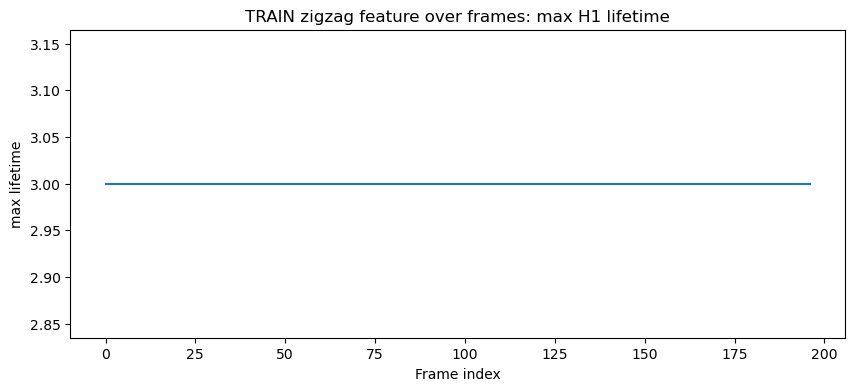

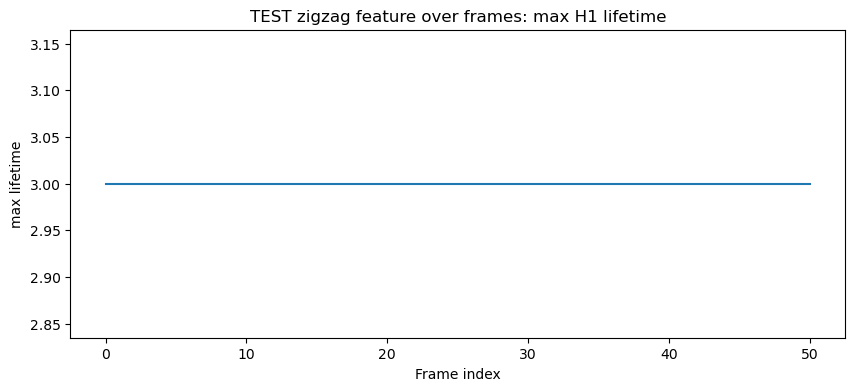

In [16]:
import numpy as np
import dionysus as d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------------------------
# Settings (tune if slow)
# --------------------------
FRAME_SIZE = 200
STRIDE     = 50
MAXDIM     = 1
MAXDIST    = 2.0

def entropy(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0:
        return 0.0
    p = x / (x.sum() + 1e-12)
    return float(-(p * np.log(p + 1e-12)).sum())

def zigzag_local_features(points_union, in_left, in_right, maxdim=1, maxdist=2.0):
    """
    True zigzag on 3 stages: Left -> Union <- Right
    using Dionysus zigzag_homology_persistence(filtration, times).

    points_union: (m, D) union points
    in_left:  boolean mask length m (True if vertex in Left frame)
    in_right: boolean mask length m (True if vertex in Right frame)

    Returns: feature vector for stage 1 (Union) based on H1 lifetimes
    """
    # Reduce to 3D for speed/stability
    pts3 = PCA(n_components=3).fit_transform(points_union)

    # Build ONE Rips filtration on union vertex set
    f = d.fill_rips(pts3, maxdim, maxdist)
    f.sort()

    # Assign simplex existence times across stages 0,1,2 (we use [birth, death) indexing)
    # Stage indices: 0=Left, 1=Union, 2=Right
    # We encode times in a 0..3 axis so that:
    # - existence in stage 0 means interval starts at 0
    # - existence through stage 1 means death >= 2
    # - existence through stage 2 means death = 3
    #
    # Rule: simplex exists in Left iff all vertices in_left
    #       simplex exists in Right iff all vertices in_right
    #       simplex always exists in Union (stage 1) because union contains all vertices

    times = []
    for s in f:
        verts = list(s)
        left_ok  = all(in_left[v]  for v in verts)
        right_ok = all(in_right[v] for v in verts)

        if left_ok and right_ok:
            times.append([0.0, 3.0])   # present in all stages
        elif left_ok and not right_ok:
            times.append([0.0, 2.0])   # stages 0 and 1
        elif (not left_ok) and right_ok:
            times.append([1.0, 3.0])   # stages 1 and 2
        else:
            times.append([1.0, 2.0])   # only stage 1

    # True zigzag persistence (supported signature in your build)
    zz, dgms, _ = d.zigzag_homology_persistence(f, times, prime=2, progress=False)

    # dgms[1] is H1 diagram
    if len(dgms) <= 1 or len(dgms[1]) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    H1 = dgms[1]
    pers = []
    for p in H1:
        b = getattr(p, "birth", None)
        dt = getattr(p, "death", None)
        if b is None or dt is None:
            try:
                b, dt = float(p[0]), float(p[1])
            except Exception:
                continue
        if np.isfinite(dt) and np.isfinite(b) and dt > b:
            pers.append(dt - b)

    pers = np.array(pers, dtype=float)
    if len(pers) == 0:
        return np.array([0, 0.0, 0.0, 0.0], dtype=float)

    return np.array([
        len(pers),
        pers.max(),
        pers.mean(),
        entropy(pers)
    ], dtype=float)

def zigzag_sequence_features(Z_last, frame_size=200, stride=50, maxdim=1, maxdist=2.0, max_pairs=None):
    """
    Computes local zigzag features for each adjacent frame pair.
    Then builds per-frame features by averaging adjacent pair features.
    Returns per-sample features (aligned to Z_last indices) and per-frame features.
    """
    frames_idx = [np.arange(i, i+frame_size) for i in range(0, len(Z_last) - frame_size + 1, stride)]
    n_frames = len(frames_idx)

    # Optional cap for speed debugging
    pair_count = n_frames - 1
    if max_pairs is not None:
        pair_count = min(pair_count, max_pairs)

    pair_feats = []
    for i in range(pair_count):
        idx_left = frames_idx[i]
        idx_right = frames_idx[i+1]

        # union index set (use sorted unique)
        idx_union = np.unique(np.concatenate([idx_left, idx_right]))
        pts_union = Z_last[idx_union]

        # map global indices -> local vertex ids 0..m-1
        pos = {g: j for j, g in enumerate(idx_union)}
        in_left  = np.zeros(len(idx_union), dtype=bool)
        in_right = np.zeros(len(idx_union), dtype=bool)

        for g in idx_left:
            in_left[pos[g]] = True
        for g in idx_right:
            in_right[pos[g]] = True

        feat = zigzag_local_features(pts_union, in_left, in_right, maxdim=maxdim, maxdist=maxdist)
        pair_feats.append(feat)

        if (i + 1) % 10 == 0:
            print(f"  computed local zigzag {i+1}/{pair_count}")

    pair_feats = np.array(pair_feats, dtype=float)  # (pair_count, 4)

    # Build per-frame features:
    # frame 0 uses pair 0
    # frame i uses average(pair i-1, pair i)
    # last frame uses last pair
    per_frame = []
    for i in range(n_frames):
        if i == 0:
            per_frame.append(pair_feats[0])
        elif i >= pair_count:
            per_frame.append(pair_feats[pair_count-1])
        else:
            per_frame.append(0.5 * (pair_feats[i-1] + pair_feats[i]))
    per_frame = np.array(per_frame, dtype=float)  # (n_frames, 4)

    # Map each sample to its frame index (same as before)
    sample_to_frame = np.minimum(np.arange(len(Z_last)) // stride, n_frames - 1)
    per_sample = per_frame[sample_to_frame]  # (N, 4)

    return per_sample, per_frame

# --------------------------
# Load latent sequences
# --------------------------
latent_train_seq = np.load("sirikit/30_day_latent_train_seq.npy")
latent_test_seq  = np.load("30_sirikit/30_day_latent_test_seq.npy")
Z_train_last = latent_train_seq[:, -1, :]
Z_test_last  = latent_test_seq[:, -1, :]

print("Z_train_last:", Z_train_last.shape)
print("Z_test_last :", Z_test_last.shape)

print("\n=== TRAIN local zigzag ===")
zigzag_train_per_sample, zigzag_train_per_frame = zigzag_sequence_features(
    Z_train_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\n=== TEST local zigzag ===")
zigzag_test_per_sample, zigzag_test_per_frame = zigzag_sequence_features(
    Z_test_last, frame_size=FRAME_SIZE, stride=STRIDE, maxdim=MAXDIM, maxdist=MAXDIST
)

print("\nShapes:")
print("zigzag_train_per_sample:", zigzag_train_per_sample.shape)
print("zigzag_test_per_sample :", zigzag_test_per_sample.shape)

np.save("30_sirikit/30_day_zigzag_train_per_sample.npy", zigzag_train_per_sample)
np.save("30_sirikit/30_day_zigzag_test_per_sample.npy", zigzag_test_per_sample)
np.save("30_sirikit/30_day_zigzag_train_per_frame.npy", zigzag_train_per_frame)
np.save("30_sirikit/30_day_zigzag_test_per_frame.npy", zigzag_test_per_frame)

print("\nSaved zigzag feature files.")

# --------------------------
# Quick visualization
# --------------------------
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 1])  # max lifetime
plt.title("TRAIN zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(zigzag_test_per_frame[:, 1])  # max lifetime
plt.title("TEST zigzag feature over frames: max H1 lifetime")
plt.xlabel("Frame index")
plt.ylabel("max lifetime")
plt.show()


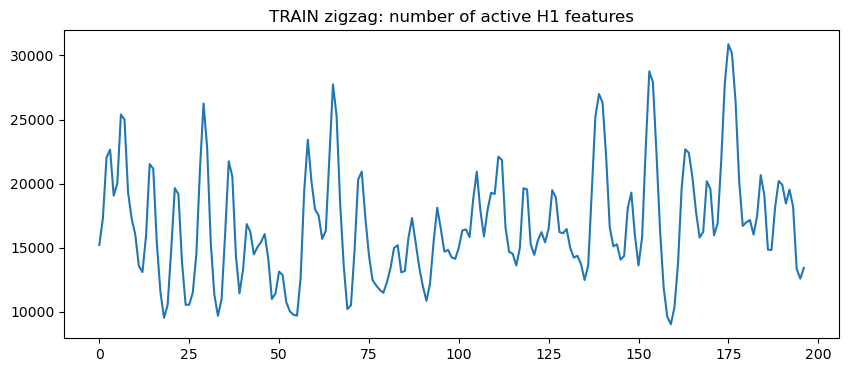

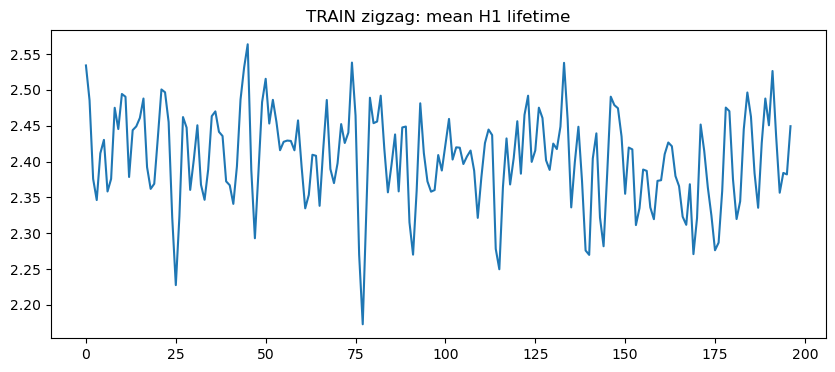

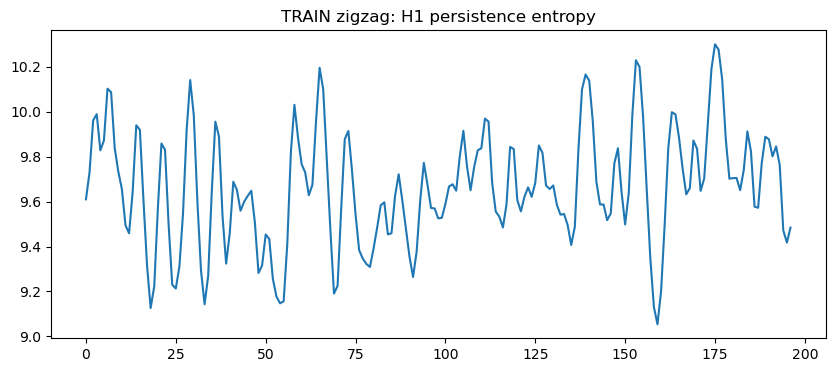

In [17]:
# 1) Number of active H1 features
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 0])
plt.title("TRAIN zigzag: number of active H1 features")
plt.show()

# 2) Mean lifetime
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 2])
plt.title("TRAIN zigzag: mean H1 lifetime")
plt.show()

# 3) Entropy (this one is key)
plt.figure(figsize=(10,4))
plt.plot(zigzag_train_per_frame[:, 3])
plt.title("TRAIN zigzag: H1 persistence entropy")
plt.show()


In [14]:
import numpy as np

# load
phi_train = np.load("sirikit/7_day_zigzag_train_per_sample.npy")
phi_test  = np.load("sirikit/7_day_zigzag_test_per_sample.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("phi_train:", phi_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("phi_test:", phi_test.shape)

# hard alignment checks
assert len(X_train) == len(phi_train), "Train mismatch: X_train and phi_train lengths differ!"
assert len(X_test)  == len(phi_test),  "Test mismatch: X_test and phi_test lengths differ!"

print("Alignment OK: phi matches X by sample index")
print("phi_train stats (mean, std):")
print(phi_train.mean(axis=0), phi_train.std(axis=0))


X_train: (10061, 180, 1)
y_train: (10061, 7)
phi_train: (10061, 4)
X_test: (2736, 180, 1)
y_test: (2736, 7)
phi_test: (2736, 4)
Alignment OK: phi matches X by sample index
phi_train stats (mean, std):
[2.05912529e+04 3.00000000e+00 2.37958630e+00 9.87904980e+00] [4.07308196e+03 0.00000000e+00 5.42467841e-02 1.93800097e-01]


## Normalize zigzag features (train-only) + remove constant column

In [18]:
import numpy as np

phi_train = np.load("30_sirikit/30_day_zigzag_train_per_sample.npy").astype(np.float32)
phi_test  = np.load("30_sirikit/30_day_zigzag_test_per_sample.npy").astype(np.float32)

# 1) detect constant columns using train
std = phi_train.std(axis=0)
keep = std > 1e-8
print("std:", std)
print("keep mask:", keep)

phi_train_k = phi_train[:, keep]
phi_test_k  = phi_test[:, keep]
print("kept dims:", phi_train_k.shape[1])

# 2) normalize using train statistics only
mu = phi_train_k.mean(axis=0, keepdims=True)
sd = phi_train_k.std(axis=0, keepdims=True) + 1e-8

phi_train_n = (phi_train_k - mu) / sd
phi_test_n  = (phi_test_k  - mu) / sd

print("normalized train mean ~0:", phi_train_n.mean(axis=0))
print("normalized train std  ~1:", phi_train_n.std(axis=0))


std: [4.389242e+03 0.000000e+00 6.472898e-02 2.545871e-01]
keep mask: [ True False  True  True]
kept dims: 3
normalized train mean ~0: [2.6753804e-07 9.7286556e-07 2.3105558e-07]
normalized train std  ~1: [1.        0.9999999 1.       ]


## Train the topo-augmented BiLSTM (baseline + augmented)

We’ll train two models:

- Baseline BiLSTM: uses only X

- Topo-aug BiLSTM: uses X + phi_norm (3 dims)

Below is a complete, minimal PyTorch setup you can paste. It assumes:

X_train, y_train, X_test, y_test are numpy arrays like your shapes show.

phi_train_n, phi_test_n are the normalized arrays we just created.

In [19]:
#3A) Dataset + DataLoader


import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y, phi=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.phi = None if phi is None else torch.tensor(phi, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.phi is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.phi[idx]

batch_size = 128

train_base = DataLoader(SeqDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_base  = DataLoader(SeqDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

train_aug  = DataLoader(SeqDataset(X_train, y_train, phi_train_n), batch_size=batch_size, shuffle=True)
test_aug   = DataLoader(SeqDataset(X_test, y_test, phi_test_n), batch_size=batch_size, shuffle=False)


In [13]:
import torch.nn as nn

class BiLSTMBase(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, out_dim=30):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        self.head = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, 2H)
        h_last = out[:, -1, :]         # (B, 2H)
        return self.head(h_last)       # (B, 7)

class BiLSTMTopoAug(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=1, topo_dim=3, out_dim=30):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + topo_dim, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x, phi):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        z = torch.cat([h_last, phi], dim=1)
        return self.head(z)

In [21]:
import torch
import numpy as np
import torch.nn as nn

def train_one(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.MSELoss()
    total = 0.0
    n = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 2:
            x, y = batch
            x, y = x.to(device), y.to(device)
            yhat = model(x)
        else:
            x, y, phi = batch
            x, y, phi = x.to(device), y.to(device), phi.to(device)
            yhat = model(x, phi)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
        n += len(x)
    return total / n

@torch.no_grad()
def eval_rmse_mae(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())

    preds = np.vstack(preds)   # shape [N, 7]
    trues = np.vstack(trues)   # shape [N, 7]

    rmse = np.sqrt(np.mean((preds - trues) ** 2))
    mae  = np.mean(np.abs(preds - trues))
    return rmse, mae

@torch.no_grad()
def eval_per_day(model, loader, device):
    model.eval()
    preds, trues = [], []
    for batch in loader:
        if len(batch) == 2:
            x, y = batch
            x = x.to(device)
            yhat = model(x).cpu().numpy()
        else:
            x, y, phi = batch
            x, phi = x.to(device), phi.to(device)
            yhat = model(x, phi).cpu().numpy()
        preds.append(yhat)
        trues.append(y.numpy())

    preds = np.vstack(preds)   # [N, 7]
    trues = np.vstack(trues)   # [N, 7]

    rmses, maes = [], []
    for h in range(preds.shape[1]):
        rmse_h = np.sqrt(np.mean((preds[:, h] - trues[:, h]) ** 2))
        mae_h  = np.mean(np.abs(preds[:, h] - trues[:, h]))
        rmses.append(rmse_h)
        maes.append(mae_h)

    return np.array(rmses), np.array(maes)

In [22]:
#3D) Run baseline vs augmented

# import os, torch

# SAVE_DIR = "sirikit"
# os.makedirs(SAVE_DIR, exist_ok=True)

best_rmse_base = float("inf")
best_rmse_aug  = float("inf")
patience = 10
no_improve_base = 0
no_improve_aug  = 0



In [23]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# reproducibility (important for comparison)
torch.manual_seed(0)
np.random.seed(0)

# ----- instantiate models -----
base = BiLSTMBase(
    input_dim=1,
    hidden_dim=128
).to(device)

aug = BiLSTMTopoAug(
    input_dim=1,
    hidden_dim=128,
    topo_dim=phi_train_n.shape[1]
).to(device)

# ----- optimizers -----
opt_base = torch.optim.Adam(base.parameters(), lr=1e-3)
opt_aug  = torch.optim.Adam(aug.parameters(),  lr=1e-3)

print("✅ Models and optimizers initialized")


Using device: cpu
✅ Models and optimizers initialized


In [24]:
import os

SAVE_DIR = "30_sirikit"
os.makedirs(SAVE_DIR, exist_ok=True)
max_epochs = 200

for ep in range(1, max_epochs + 1):
    lb = train_one(base, train_base, opt_base, device)
    la = train_one(aug,  train_aug,  opt_aug,  device)

    rmse_b, mae_b = eval_rmse_mae(base, test_base, device)
    rmse_a, mae_a = eval_rmse_mae(aug,  test_aug,  device)

    print(f"Epoch {ep:02d} | base loss {lb:.4f} rmse {rmse_b:.4f} mae {mae_b:.4f} "
          f"| aug loss {la:.4f} rmse {rmse_a:.4f} mae {mae_a:.4f}")

    # ---- baseline checkpoint ----
    if rmse_b < best_rmse_base - 1e-6:
        best_rmse_base = rmse_b
        no_improve_base = 0
        torch.save({
            "model_state": base.state_dict(),
            "optimizer_state": opt_base.state_dict(),
            "rmse": rmse_b,
            "config": {"model":"BiLSTMBase","input_dim":1,"out_dim": 30,"hidden_dim":128,"lookback": X_train.shape[1]}
        }, f"{SAVE_DIR}/30_day_bilstm_base_best_sirikit.pt")
        print(" Saved best baseline")
    else:
        no_improve_base += 1

    # ---- topo-aug checkpoint ----
    if rmse_a < best_rmse_aug - 1e-6:
        best_rmse_aug = rmse_a
        no_improve_aug = 0
        torch.save({
            "model_state": aug.state_dict(),
            "optimizer_state": opt_aug.state_dict(),
            "rmse": rmse_a,
            "config": {"model":"BiLSTMTopoAug","input_dim":1,"out_dim": 30,"hidden_dim":128,"topo_dim":phi_train_n.shape[1],"lookback": X_train.shape[1]},
            "zigzag_norm": {"mu": mu, "sd": sd, "keep_mask": keep}
        }, f"{SAVE_DIR}/30_day_bilstm_topo_aug_best_sirikit.pt")
        print("Saved best topo-aug")
    else:
        no_improve_aug += 1

    # ---- early stopping condition (stop when BOTH stop improving) ----
    if no_improve_base >= patience and no_improve_aug >= patience:
        print(f"⏹ Early stopping at epoch {ep} (no improvement for {patience} epochs).")
        break

print("Best RMSE baseline:", best_rmse_base)
print("Best RMSE topo-aug:", best_rmse_aug)


Epoch 01 | base loss 0.3529 rmse 0.3428 mae 0.2463 | aug loss 0.3154 rmse 0.3559 mae 0.2613
 Saved best baseline
Saved best topo-aug
Epoch 02 | base loss 0.1225 rmse 0.3349 mae 0.2317 | aug loss 0.1073 rmse 0.3281 mae 0.2256
 Saved best baseline
Saved best topo-aug
Epoch 03 | base loss 0.1099 rmse 0.3098 mae 0.2097 | aug loss 0.0915 rmse 0.3123 mae 0.2140
 Saved best baseline
Saved best topo-aug
Epoch 04 | base loss 0.1087 rmse 0.3105 mae 0.2183 | aug loss 0.0889 rmse 0.3355 mae 0.2315
Epoch 05 | base loss 0.1077 rmse 0.3128 mae 0.2124 | aug loss 0.0804 rmse 0.2999 mae 0.1985
Saved best topo-aug
Epoch 06 | base loss 0.0995 rmse 0.2996 mae 0.1977 | aug loss 0.0767 rmse 0.2945 mae 0.1885
 Saved best baseline
Saved best topo-aug
Epoch 07 | base loss 0.0965 rmse 0.2965 mae 0.1922 | aug loss 0.0745 rmse 0.3042 mae 0.1974
 Saved best baseline
Epoch 08 | base loss 0.0916 rmse 0.3080 mae 0.2046 | aug loss 0.0739 rmse 0.2993 mae 0.1914
Epoch 09 | base loss 0.0870 rmse 0.3779 mae 0.2631 | aug lo

# Vizualization and Analysis

In [11]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_b = torch.load("30_sirikit/30_day_bilstm_base_best_sirikit.pt", map_location=device, weights_only=False)
ckpt_a = torch.load("30_sirikit/30_day_bilstm_topo_aug_best_sirikit.pt", map_location=device, weights_only=False)

print("Loaded checkpoints with weights_only=False")
print("baseline keys:", ckpt_b.keys())
print("aug keys:", ckpt_a.keys())


Loaded checkpoints with weights_only=False
baseline keys: dict_keys(['model_state', 'optimizer_state', 'rmse', 'config'])
aug keys: dict_keys(['model_state', 'optimizer_state', 'rmse', 'config', 'zigzag_norm'])


In [14]:
import torch, numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- load baseline checkpoint ----
ckpt_b = torch.load(
    "30_sirikit/30_day_bilstm_base_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

base_best = BiLSTMBase(
    input_dim=ckpt_b["config"]["input_dim"],
    hidden_dim=ckpt_b["config"]["hidden_dim"],
    out_dim=ckpt_b["config"]["out_dim"]
).to(device)
base_best.load_state_dict(ckpt_b["model_state"])
base_best.eval()

# ---- load topo-aug checkpoint ----
ckpt_a = torch.load(
    "30_sirikit/30_day_bilstm_topo_aug_best_sirikit.pt",
    map_location=device,
    weights_only=False
)

aug_best = BiLSTMTopoAug(
    input_dim=ckpt_a["config"]["input_dim"],
    hidden_dim=ckpt_a["config"]["hidden_dim"],
    topo_dim=ckpt_a["config"]["topo_dim"],
    out_dim=ckpt_a["config"]["out_dim"]
).to(device)
aug_best.load_state_dict(ckpt_a["model_state"])
aug_best.eval()

# ---- restore zigzag normalization from checkpoint ----
mu = ckpt_a["zigzag_norm"]["mu"]
sd = ckpt_a["zigzag_norm"]["sd"]
keep = ckpt_a["zigzag_norm"]["keep_mask"]

print("Loaded best models.")
print("Baseline best RMSE:", ckpt_b["rmse"])
print("Topo-aug best RMSE:", ckpt_a["rmse"])
print("Topo keep mask:", keep)

Loaded best models.
Baseline best RMSE: 0.29513985
Topo-aug best RMSE: 0.26311862
Topo keep mask: [ True False  True  True]


## Recreate phi_test_n exactly like training (from checkpoint

In [15]:
import numpy as np

phi_test_raw = np.load("30_sirikit/30_day_zigzag_test_per_sample.npy").astype(np.float32)

# keep only non-constant columns (same mask as training)
phi_test_k = phi_test_raw[:, keep]

# normalize using train stats saved in checkpoint
phi_test_n = (phi_test_k - mu) / (sd + 1e-8)

print("phi_test_n shape:", phi_test_n.shape)
print("phi_test_n mean/std (rough):", phi_test_n.mean(axis=0), phi_test_n.std(axis=0))


phi_test_n shape: (2713, 3)
phi_test_n mean/std (rough): [-0.02550042 -0.14576858  0.03555451] [0.6841644 1.1449034 0.7077674]


## Helper functions (latent extraction + prediction)

In [16]:
import torch
import numpy as np

@torch.no_grad()
def extract_h_last_from_lstm(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    outs = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        out, _ = model.lstm(xb)       # (B, T, 2H)
        h_last = out[:, -1, :]        # (B, 2H)
        outs.append(h_last.cpu().numpy())
    return np.vstack(outs)            # (N, 2H)

@torch.no_grad()
def predict_base(model, X_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yhat = model(xb).cpu().numpy()    # (B, 7)
        preds.append(yhat)
    return np.vstack(preds)               # (N, 7)

@torch.no_grad()
def predict_aug(model, X_np, phi_np, device, batch_size=256):
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32)
    P = torch.tensor(phi_np, dtype=torch.float32)
    preds = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        pb = P[i:i+batch_size].to(device)
        yhat = model(xb, pb).cpu().numpy()   # (B, 7)
        preds.append(yhat)
    return np.vstack(preds)                  # (N, 7)

## Extract latents + do PCA→3D + compute errors

In [17]:
from sklearn.decomposition import PCA
import numpy as np

# 1) Extract last hidden state (test set is enough to start)
Zb_te = extract_h_last_from_lstm(base_best, X_test, device)
Za_te = extract_h_last_from_lstm(aug_best,  X_test, device)

print("Zb_te:", Zb_te.shape, "Za_te:", Za_te.shape)

# 2) Fit PCA on *combined* test latents for a fair comparison
Z_all = np.vstack([Zb_te, Za_te])
pca = PCA(n_components=3, random_state=0).fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

# 3) Predictions + per-sample absolute errors
pred_b = predict_base(base_best, X_test, device)            # (N, 7)
pred_a = predict_aug(aug_best, X_test, phi_test_n, device) # (N, 7)

err_b = np.mean(np.abs(pred_b - y_test), axis=1)   # (N,)
err_a = np.mean(np.abs(pred_a - y_test), axis=1)   # (N,)

print("Pred shapes:", pred_b.shape, pred_a.shape)
print("Error shapes:", err_b.shape, err_a.shape)
print("Error mean baseline vs aug:", err_b.mean(), err_a.mean())

Zb_te: (2713, 256) Za_te: (2713, 256)
Pred shapes: (2713, 30) (2713, 30)
Error shapes: (2713,) (2713,)
Error mean baseline vs aug: 0.1923701100921407 0.16148345441570333


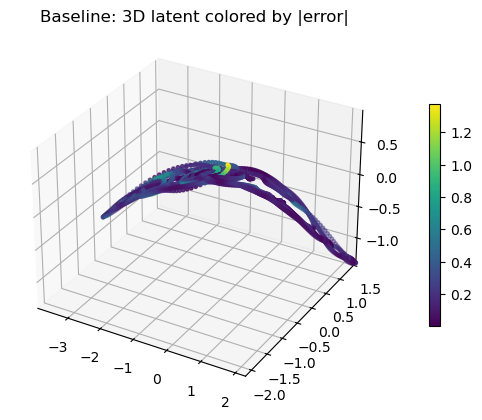

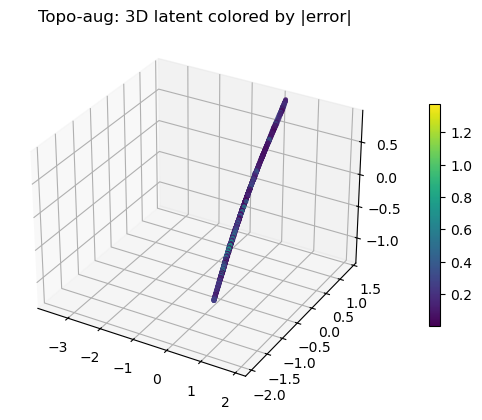

In [30]:
## 3D scatter plots (colored by error)

import numpy as np
import matplotlib.pyplot as plt

def plot_3d_same_axes(Z3, values, title, lims, vmin=None, vmax=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], s=6, c=values, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    ax.set_title(title)

    ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
    plt.show()

# shared limits across both
lims = (
    (min(Zb_te3[:,0].min(), Za_te3[:,0].min()), max(Zb_te3[:,0].max(), Za_te3[:,0].max())),
    (min(Zb_te3[:,1].min(), Za_te3[:,1].min()), max(Zb_te3[:,1].max(), Za_te3[:,1].max())),
    (min(Zb_te3[:,2].min(), Za_te3[:,2].min()), max(Zb_te3[:,2].max(), Za_te3[:,2].max())),
)

# shared color scale too
vmin = min(err_b.min(), err_a.min())
vmax = max(err_b.max(), err_a.max())

plot_3d_same_axes(Zb_te3, err_b, "Baseline: 3D latent colored by |error|", lims, vmin, vmax)
plot_3d_same_axes(Za_te3, err_a, "Topo-aug: 3D latent colored by |error|", lims, vmin, vmax)

## Where along this latent curve does topology change?

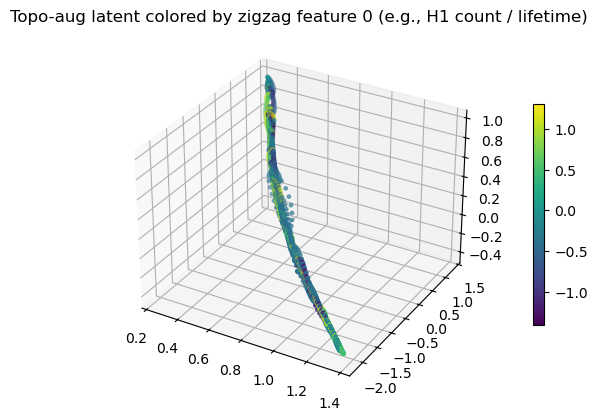

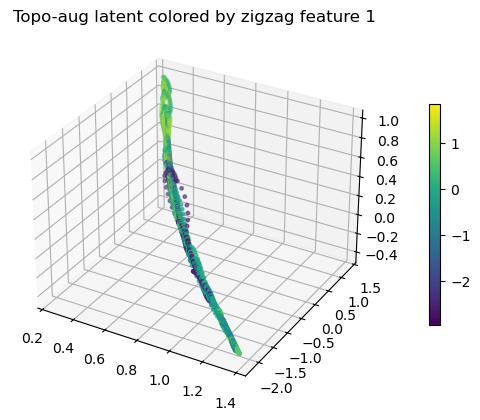

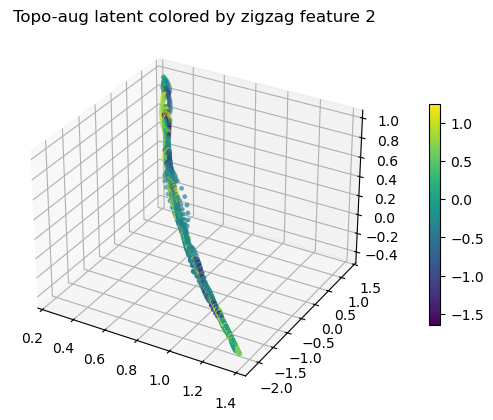

In [32]:
plot_3d(Za_te3, phi_test_n[:,0],
        "Topo-aug latent colored by zigzag feature 0 (e.g., H1 count / lifetime)")

plot_3d(Za_te3, phi_test_n[:,1],
        "Topo-aug latent colored by zigzag feature 1")

plot_3d(Za_te3, phi_test_n[:,2],
        "Topo-aug latent colored by zigzag feature 2")


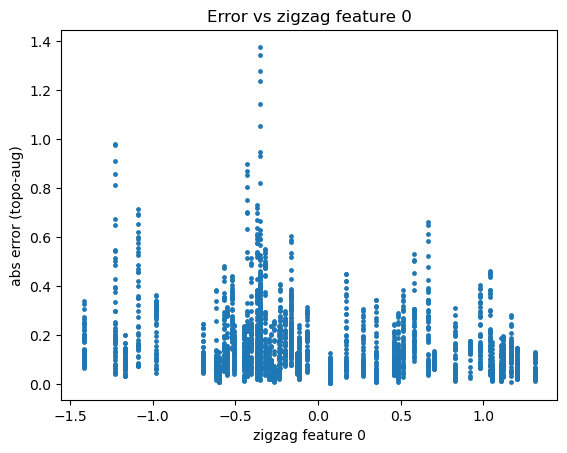

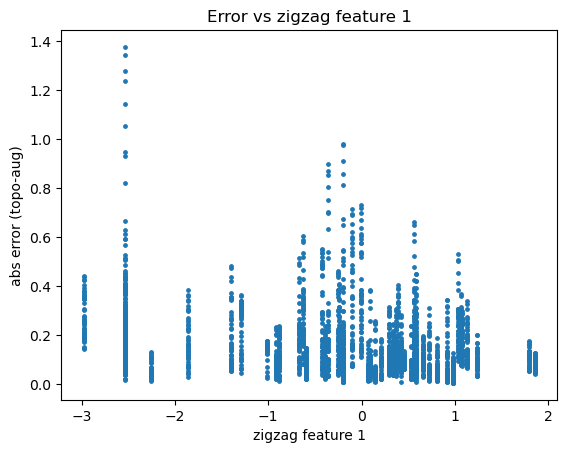

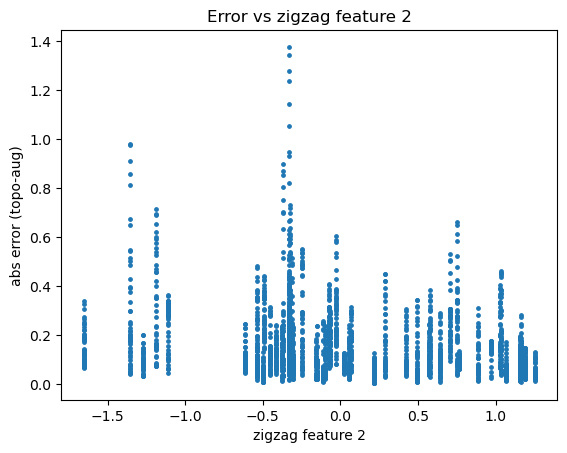

In [33]:
import matplotlib.pyplot as plt

for i in range(phi_test_n.shape[1]):
    plt.figure()
    plt.scatter(phi_test_n[:, i], err_a, s=6)
    plt.xlabel(f"zigzag feature {i}")
    plt.ylabel("abs error (topo-aug)")
    
    plt.title(f"Error vs zigzag feature {i}")
    plt.show()


In [34]:
# choose zigzag feature that looks strongest (start with feature 2)
zz = phi_test_n[:, 2]

# get indices of top and bottom 1%
hi_idx = np.argsort(zz)[-int(0.01 * len(zz)):]
lo_idx = np.argsort(zz)[:int(0.01 * len(zz)):]

print("High zigzag indices:", hi_idx[:5])
print("Low zigzag indices:", lo_idx[:5])


High zigzag indices: [1965 1996 1963 1986 1987]
Low zigzag indices: [951 973 972 971 970]


## Save the cache

In [35]:
import numpy as np

np.save("30_sirikit/30_day_cache_Zb_te.npy", Zb_te)
np.save("30_sirikit/30_day_cache_Za_te.npy", Za_te)
np.save("30_sirikit/30_day_cache_Zb_te3.npy", Zb_te3)
np.save("30_sirikit/30_day_cache_Za_te3.npy", Za_te3)
np.save("30_sirikit/30_day_cache_pred_b.npy", pred_b)
np.save("30_sirikit/30_day_cache_pred_a.npy", pred_a)
np.save("30_sirikit/30_day_cache_err_b.npy", err_b)
np.save("30_sirikit/30_day_cache_err_a.npy", err_a)
np.save("30_sirikit/30_day_cache_phi_test_n.npy", phi_test_n)
np.save("30_sirikit/30_day_cache_hi_idx.npy", hi_idx)
np.save("30_sirikit/30_day_cache_lo_idx.npy", lo_idx)

print("Cached arrays saved")


Cached arrays saved


In [36]:
import os

os.listdir("30_sirikit")


['30_day_cache_err_a.npy',
 '30_day_cache_hi_idx.npy',
 '30_day_zigzag_test_per_frame.npy',
 '30_day_zigzag_train_per_frame.npy',
 '30_day_cache_Za_te3.npy',
 '30_day_cache_lo_idx.npy',
 '30_day_cache_err_b.npy',
 '30_day_zigzag_train_per_sample.npy',
 '30_day_cache_Zb_te3.npy',
 '30_day_y_true_test.npy',
 '30_day_bilstm_topo_aug_best_sirikit.pt',
 '30_day_zigzag_test_per_sample.npy',
 '30_day_bilstm_base_best_sirikit.pt',
 '30_day_cache_phi_test_n.npy',
 '30_day_cache_pred_b.npy',
 '30_day_cache_Zb_te.npy',
 '30_day_cache_pred_a.npy',
 '30_day_latent_test_seq.npy',
 '30_day_y_pred_test.npy',
 '30_day_cache_Za_te.npy']

## Forecast: True vs Predictions

In [37]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_full_base(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)   # [B,180,1]
            yb = yb.to(device)   # [B,7]

            out = model(xb)      # [B,7]

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

def eval_full_aug(model, loader, device):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for batch in loader:
            xb  = batch[0].to(device)   # [B,180,1]
            yb  = batch[1].to(device)   # [B,7]
            phi = batch[2].to(device)   # [B,k]

            out = model(xb, phi)        # [B,7]

            ys.append(yb.detach().cpu().numpy())
            preds.append(out.detach().cpu().numpy())

    y_true = np.concatenate(ys).ravel()
    y_pred = np.concatenate(preds).ravel()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae, y_true, y_pred

rmse_b, mae_b, y_true_b, y_pred_b = eval_full_base(base_best, test_base, device)
rmse_a, mae_a, y_true_a, y_pred_a = eval_full_aug(aug_best, test_aug, device)

print(rmse_b, mae_b, y_true_b.shape, y_pred_b.shape)
print(rmse_a, mae_a, y_true_a.shape, y_pred_a.shape)

print("max |True - Baseline| :", np.max(np.abs(y_true_b - y_pred_b)))
print("max |True - Topo|     :", np.max(np.abs(y_true_b - y_pred_a)))
print("max |Baseline - Topo| :", np.max(np.abs(y_pred_b - y_pred_a)))

0.29513983851012005 0.19237008690834045 (81390,) (81390,)
0.2631186297182428 0.16148345172405243 (81390,) (81390,)
max |True - Baseline| : 2.1928964
max |True - Topo|     : 2.3096418
max |Baseline - Topo| : 2.1859057


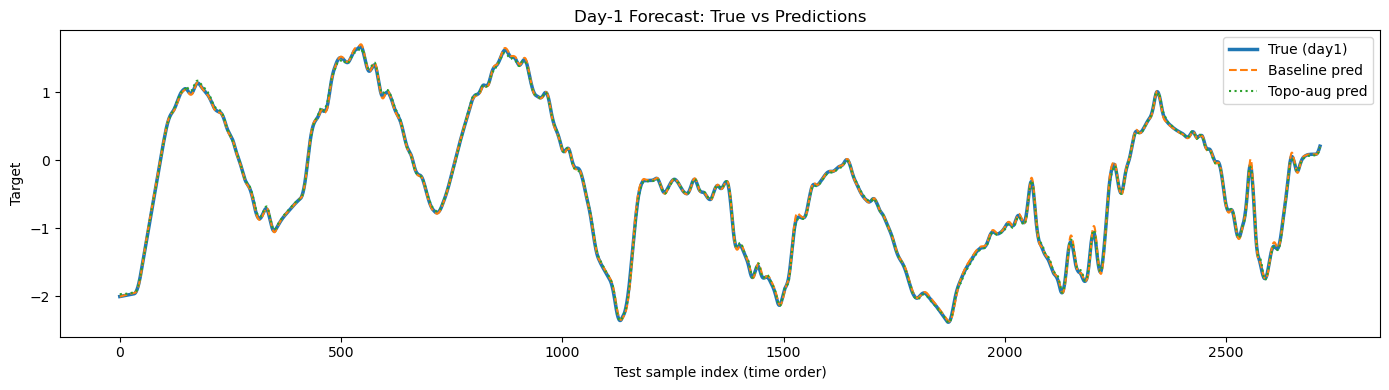

In [38]:
plt.figure(figsize=(14,4))

plt.plot(y_test[:,0], label="True (day1)", linewidth=2.5)
plt.plot(pred_b[:,0], label="Baseline pred", linestyle="--")
plt.plot(pred_a[:,0], label="Topo-aug pred", linestyle=":")

plt.title("Day-1 Forecast: True vs Predictions")
plt.xlabel("Test sample index (time order)")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

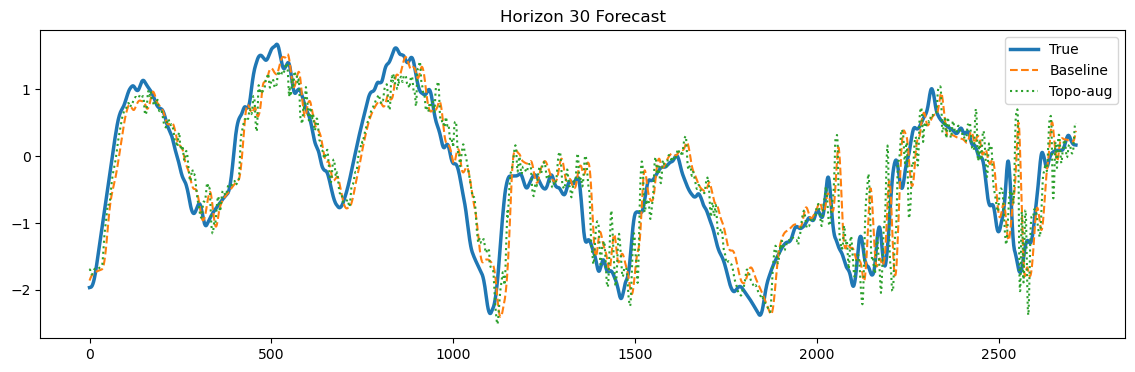

In [41]:
h = 29   # choose horizon

plt.figure(figsize=(14,4))
plt.plot(y_test[:,h], label="True", linewidth=2.5)
plt.plot(pred_b[:,h], label="Baseline", linestyle="--")
plt.plot(pred_a[:,h], label="Topo-aug", linestyle=":")
plt.title(f"Horizon {h+1} Forecast")
plt.legend()
plt.show()

## Step Variance

In [46]:
from sklearn.decomposition import PCA
import numpy as np

# Zb_te: (N, D) baseline latents
# Za_te: (N, D) topo-aug latents

Z_all = np.vstack([Zb_te, Za_te])

pca = PCA(n_components=3, random_state=0)
pca.fit(Z_all)

Zb_te3 = pca.transform(Zb_te)
Za_te3 = pca.transform(Za_te)

In [47]:
d_b = np.linalg.norm(Zb_te[1:] - Zb_te[:-1], axis=1)
d_a = np.linalg.norm(Za_te[1:] - Za_te[:-1], axis=1)

print("Baseline step variance:", d_b.std())
print("Topo-aug step variance:", d_a.std())

Baseline step variance: 0.028002338
Topo-aug step variance: 0.019959588


In [48]:
print("Baseline mean step:", d_b.mean(), "std:", d_b.std())
print("Topo-aug mean step:", d_a.mean(), "std:", d_a.std())

Baseline mean step: 0.03818723 std: 0.028002338
Topo-aug mean step: 0.02619676 std: 0.019959588


In [49]:
import numpy as np

def perm_test_var_ratio(a, b, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    obs = np.var(a) / np.var(b)
    pooled = np.concatenate([a, b])
    n = len(a)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        a_p = pooled[:n]
        b_p = pooled[n:]
        stat = np.var(a_p) / np.var(b_p)
        if stat >= obs:
            count += 1
    return obs, (count + 1) / (n_perm + 1)

obs, p = perm_test_var_ratio(d_b, d_a)
print("Var ratio (baseline/topo):", obs, "p-value:", p)

Var ratio (baseline/topo): 1.9682736 p-value: 0.0001999600079984003


## Local neighborhood scale (kNN radius) over time

kNN radius mean baseline: 0.07395016158243709
kNN radius mean topo:     0.048381726831478206


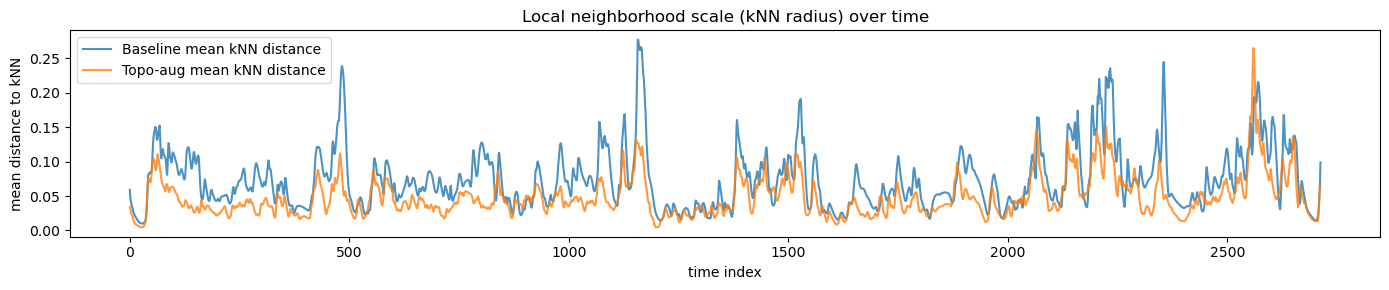

kNN radius std baseline: 0.0434058529875696
kNN radius std topo:     0.02898717219413189


In [50]:
from sklearn.neighbors import NearestNeighbors
import numpy as np, matplotlib.pyplot as plt

def knn_radius(Z, k=10):
    nn = NearestNeighbors(n_neighbors=k+1).fit(Z)
    dists, _ = nn.kneighbors(Z)        # first neighbor is itself
    return dists[:, 1:].mean(axis=1)   # mean distance to k nearest neighbors

r_b = knn_radius(Zb_te, k=10)
r_a = knn_radius(Za_te, k=10)

print("kNN radius mean baseline:", r_b.mean())
print("kNN radius mean topo:    ", r_a.mean())

#topo model → slightly tighter + more stable geometry if less val

plt.figure(figsize=(14,3))
plt.plot(r_b, label="Baseline mean kNN distance", alpha=0.8)
plt.plot(r_a, label="Topo-aug mean kNN distance", alpha=0.8)
plt.title("Local neighborhood scale (kNN radius) over time")
plt.xlabel("time index")
plt.ylabel("mean distance to kNN")
plt.legend()
plt.tight_layout()
plt.show()

print("kNN radius std baseline:", r_b.std())
print("kNN radius std topo:    ", r_a.std())

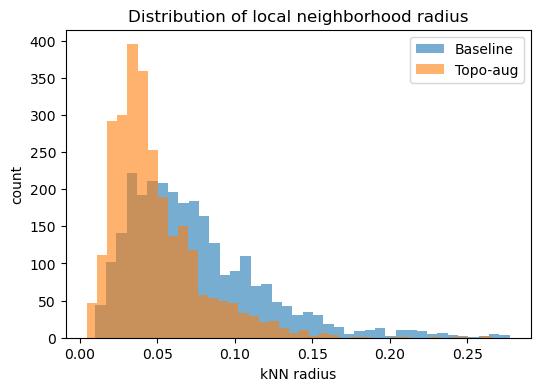

In [51]:
plt.figure(figsize=(6,4))
plt.hist(r_b, bins=40, alpha=0.6, label="Baseline")
plt.hist(r_a, bins=40, alpha=0.6, label="Topo-aug")
plt.xlabel("kNN radius")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of local neighborhood radius")
plt.show()

 ## F- statistics

In [54]:
import numpy as np
from scipy.stats import f

n_b = len(r_b)
n_a = len(r_a)

var_b = np.var(r_b, ddof=1)
var_a = np.var(r_a, ddof=1)

if var_b > var_a:
    F = var_b / var_a
    df1 = n_b - 1
    df2 = n_a - 1
else:
    F = var_a / var_b
    df1 = n_a - 1
    df2 = n_b - 1

p_value = 2 * (1 - f.cdf(F, df1, df2))

print("Variance baseline:", var_b)
print("Variance topo:", var_a)
print("F statistic:", F)
print("p-value:", p_value)

Variance baseline: 0.001884762788944868
Variance topo: 0.0008405659807767856
F statistic: 2.2422544238622617
p-value: 2.220446049250313e-16


In [55]:
print("Variance ratio (baseline/topo):", var_b / var_a)

Variance ratio (baseline/topo): 2.2422544238622617


## Plots

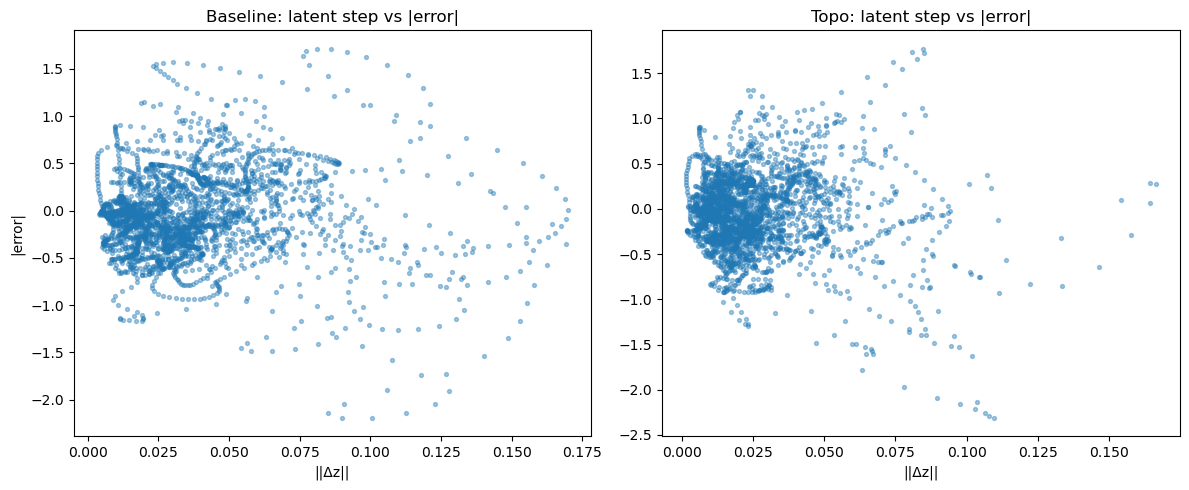

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(d_b, err_b_aligned, s=8, alpha=0.4)
plt.title("Baseline: latent step vs |error|")
plt.xlabel("||Δz||")
plt.ylabel("|error|")

plt.subplot(1,2,2)
plt.scatter(d_a, err_a_aligned, s=8, alpha=0.4)
plt.title("Topo: latent step vs |error|")
plt.xlabel("||Δz||")

plt.tight_layout()
plt.show()